Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from textblob import TextBlob

Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\waldi\Downloads\data-science-datasets-main\Task 4\twitter_training.csv",
    header=None
)

print(df.head())

      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


Adding Column names

In [4]:
df.columns = ['ID', 'Topic', 'Sentiment', 'Text']

Checking Missing Values

In [5]:
print(df.isnull().sum())

ID             0
Topic          0
Sentiment      0
Text         686
dtype: int64


Removing missing rows

In [6]:
df.dropna(inplace=True)

Function for sentiment analysis

In [7]:
def get_sentiment(text):
    
    analysis = TextBlob(str(text))
    
    polarity = analysis.sentiment.polarity
    
    if polarity > 0:
        return 'Positive'
    
    elif polarity < 0:
        return 'Negative'
    
    else:
        return 'Neutral'

Creating predicted sentiment column

In [8]:
df['Predicted_Sentiment'] = df['Text'].apply(get_sentiment)

Checking results

In [9]:
print(df[['Text', 'Predicted_Sentiment']].head())

                                                Text Predicted_Sentiment
0  im getting on borderlands and i will murder yo...             Neutral
1  I am coming to the borders and I will kill you...             Neutral
2  im getting on borderlands and i will kill you ...             Neutral
3  im coming on borderlands and i will murder you...             Neutral
4  im getting on borderlands 2 and i will murder ...             Neutral


Counting sentiments

In [10]:
sentiment_counts = df['Predicted_Sentiment'].value_counts()

print(sentiment_counts)

Predicted_Sentiment
Positive    34074
Negative    21358
Neutral     18564
Name: count, dtype: int64


Bar chart visualization

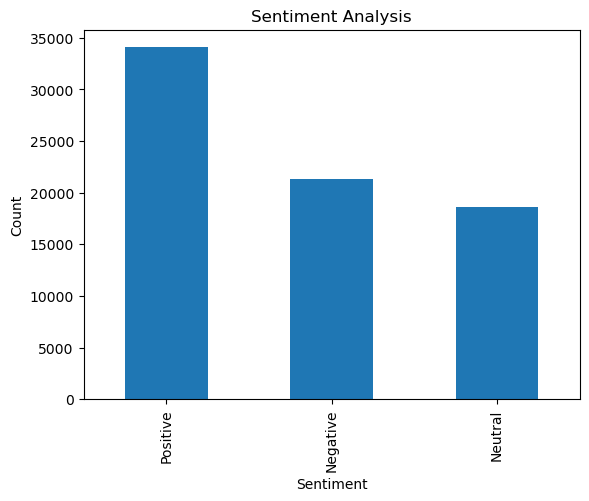

In [11]:
sentiment_counts.plot(kind='bar')

plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.title("Sentiment Analysis")

plt.show()

Pie chart visualization

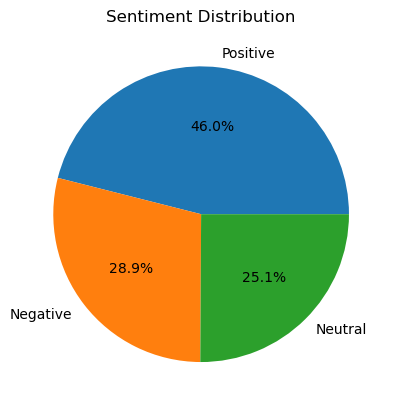

In [12]:
sentiment_counts.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sentiment Distribution")

plt.ylabel('')

plt.show()

This project analyzes social media sentiment using TextBlob. The sentiments were classified into Positive, Negative, and Neutral categories. Visualizations such as bar charts and pie charts were used to understand public opinion trends.